In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import scanpy as sc
import seaborn as sns
import warnings

warnings.simplefilter("ignore", FutureWarning)
warnings.simplefilter("ignore", UserWarning)
warnings.simplefilter("ignore", RuntimeWarning)

plt.rcParams['font.family'] = 'Arial'

/mnt/home/terrianl/anaconda3/envs/scanpyEnv/lib/python3.11/site-packages/scvi/_settings.py:63: UserWarning: Since v1.0.0, scvi-tools no longer uses a random seed by default. Run `scvi.settings.seed = 0` to reproduce results from previous versions.
  self.seed = seed
/mnt/home/terrianl/anaconda3/envs/scanpyEnv/lib/python3.11/site-packages/scvi/_settings.py:70: UserWarning: Setting `dl_pin_memory_gpu_training` is deprecated in v1.0 and will be removed in v1.1. Please pass in `pin_memory` to the data loaders instead.
  self.dl_pin_memory_gpu_training = (


In [ ]:
### Load the Meso data
adata_meso = sc.read_h5ad("../data/adata_all_samples_preprocessed.h5ad")
annotate = sc.read_h5ad('../data/adata_all_samples_annotated.h5ad')

### Then we add annotations
adata_meso.obs['celltype'] = annotate.obs.celltype.copy() 
adata_meso.obs['celltype_broad'] = annotate.obs.celltype_broad.copy()

### Where the celltype_broad equals neuronal_cells, we'll change it to schwann_cells
adata_meso.obs['celltype_broad'] = adata_meso.obs['celltype_broad'].replace(['Neuronal_Cells'], 'Schwann_Cells')

### Set the celltype_broad adipocytes to be split into white and brown, based on the celltype column
# Replace Adipocytes in celltype_broad based on celltype values
# Convert to string, make changes, convert back to category
adata_meso.obs['celltype_broad'] = adata_meso.obs['celltype_broad'].astype(str)
mask = adata_meso.obs['celltype_broad'] == 'Adipocytes'
adata_meso.obs.loc[mask, 'celltype_broad'] = adata_meso.obs.loc[mask, 'celltype']
adata_meso.obs['celltype_broad'] = adata_meso.obs['celltype_broad'].astype('category')

### Select only the Meso samples from the thoracic aorta PVAT
adata_meso = adata_meso[adata_meso.obs.tissue == 'Thoracic_Aorta'].copy()
### Add columns that exist in the taPVAT data but not in the Meso data, so that we can concatenate them later
adata_meso.obs['sex'] = 'M'

In [ ]:
### Load the taPVAT data
### You may download taPVAT data at GEO Accession ID GSE307140
filepath = "path/to/taPVAT_data/"  ### Note that the file path needs to be changed!
adata_tapvat = sc.read_h5ad(filepath + "taPVAT_8W_24W_M_F_HF_CTRL_combined_preprocessed.h5ad")
annotate = sc.read_h5ad(filepath + "taPVAT_combined_annotated_with_immune_fibro_ecs.h5ad")

### Then we add annotations and adjust to match the Meso data
adata_tapvat.obs['celltype'] = annotate.obs.celltype.copy() 
adata_tapvat.obs['celltype_broad'] = annotate.obs.celltype_broad.copy() 
adata_tapvat.obs['celltype'] = annotate.obs.celltype.copy() 

### Where the celltype equals Adipocytes_2 or adipocytes_3, we'll change it to adipocytes white
adata_tapvat.obs['celltype'] = adata_tapvat.obs['celltype'].replace(['Adipocytes_2', 'Adipocytes_3'], 'Adipocytes_White')
### Where the celltype equals pericytes or smcs, we'll change it to pericytes_smcs
adata_tapvat.obs['celltype_broad'] = adata_tapvat.obs['celltype_broad'].replace(['Pericytes', 'SMCs'], 'Pericytes_SMCs')
### Where the celltype_broad equals neuronal_cells, we'll change it to schwann_cells
adata_tapvat.obs['celltype_broad'] = adata_tapvat.obs['celltype_broad'].replace(['Neuronal_Cells'], 'Schwann_Cells')

### Set the celltype_broad adipocytes to be split into white and brown, based on the celltype column
# Replace Adipocytes in celltype_broad based on celltype values
# Convert to string, make changes, convert back to category
adata_tapvat.obs['celltype_broad'] = adata_tapvat.obs['celltype_broad'].astype(str)
mask = adata_tapvat.obs['celltype_broad'] == 'Adipocytes'
adata_tapvat.obs.loc[mask, 'celltype_broad'] = adata_tapvat.obs.loc[mask, 'celltype']
adata_tapvat.obs['celltype_broad'] = adata_tapvat.obs['celltype_broad'].astype('category')

### Drop the doublet celltype
adata_tapvat = adata_tapvat[adata_tapvat.obs['celltype'] != 'Doublets'].copy()

### Select only the 24W Male rats on control diet
adata_tapvat = adata_tapvat[adata_tapvat.obs.sample_type == 'taPVAT_Control_24W_M'].copy()
### Drop irrelevant columns

### Add columns that exist in the Meso data but not in the taPVAT data, so that we can concatenate them later
adata_tapvat.obs['platform'] = '10x'
adata_tapvat.obs['strain'] = 'Dahl_SS'
adata_tapvat.obs['species'] = 'Rattus_Norvegicus'
adata_tapvat.obs['tissue_type'] = 'Adipose'
adata_tapvat.obs['sample'] = adata_tapvat.obs['sample_id']
adata_tapvat.obs['sample_id'] = adata_tapvat.obs['Sample']


In [73]:
### Combine the two datasets
adata = adata_meso.concatenate(adata_tapvat, batch_key = 'batch_key', join = 'outer', fill_value=0)
adata.var_names_make_unique()

In [74]:
adata.obs.celltype.value_counts()

Adipocytes_Brown             7503
Mesothelial_Cells            3359
Adipocytes_White             1926
Fibroblasts                  1661
ECs_Cap                      1571
Endothelial_Cells            1203
Pericytes_SMCs                880
Unknown                       708
Immune_Cells                  608
ECs_Artery                    530
Fibroblasts_Bmper+_Nrxn1+     404
Pericytes                     376
Schwann_Cells                 272
ECs_Venous                    137
Fibroblasts_Pi16+              95
ECs_Venous_Fbn1+               91
Fibroblasts_Bmper+             88
Macrophages_M2                 82
Macrophages_M2_F13a1+          73
Fibroblasts_Pi16++             73
ECs_Lymph_Piezo2+              47
ECs_Lymph                      43
NK_Cells                       37
T_Cells                        36
Macrophages_M1_Cd80+           35
SMCs                           31
B_Cells_Naive                  20
Neuronal_Cells                 19
Dendritic_Cells                13
T_Regs        

In [75]:
adata.obs.celltype_broad.value_counts()

Adipocytes_Brown     7503
Endothelial_Cells    3622
Mesothelial_Cells    3359
Fibroblasts          2321
Adipocytes_White     1926
Pericytes_SMCs       1287
Immune_Cells          916
Unknown               708
Schwann_Cells         291
Name: celltype_broad, dtype: int64

In [76]:
df = adata.var.filter(like='gene_ids-', axis=1)
df

,gene_ids-0,gene_ids-1
1700066B19Rik,ENSRNOG00000066011,ENSRNOG00000066011
3110082J24Rik,ENSRNOG00000046262,ENSRNOG00000046262
4930404H24Rik,NaN,ENSRNOG00000063306
4930455H04Rik,ENSRNOG00000070759,ENSRNOG00000070759
4933400A11Rik,ENSRNOG00000003688,ENSRNOG00000003688
...,...,...
mrpl24,ENSRNOG00000022234,ENSRNOG00000022234
mrpl9,ENSRNOG00000020869,ENSRNOG00000020869
pramef20l,ENSRNOG00000046931,NaN
rnf141,ENSRNOG00000062870,ENSRNOG00000062870


In [77]:
### This fills in the missing values in gene_ids-0
df['combined'] = df['gene_ids-0'].fillna(df['gene_ids-1'])
### If the above function worked properly, this will return False.
df.combined.isna().unique()

/tmp/ipykernel_486346/4143758557.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['combined'] = df['gene_ids-0'].fillna(df['gene_ids-1'])


array([False])

In [78]:
#There's no need to have so many columns in adata.var, so let's drop them
adata.var = adata.var.drop(adata.var.columns, axis = 1)

In [79]:
#Now we'll add back the one's we need
adata.var['gene_ids'] = df['combined']

In [80]:
#recalculate QC metrics
# mitochondrial genes
adata.var["mt"] = adata.var_names.str.startswith("Mt-")
# ribosomal genes
adata.var["ribo"] = adata.var_names.str.startswith(("Rps", "Rpl"))
# hemoglobin genes.
adata.var["hb"] = adata.var_names.str.contains(("^Hb[^(P)]"))

sc.pp.calculate_qc_metrics(adata, qc_vars=["mt", "ribo", "hb"], 
                           inplace=True, percent_top=[20], log1p=True)

In [81]:
adata.var

,gene_ids,mt,ribo,hb,n_cells_by_counts,mean_counts,log1p_mean_counts,pct_dropout_by_counts,total_counts,log1p_total_counts
1700066B19Rik,ENSRNOG00000066011,False,False,False,2,0.000091,0.000091,99.990881,2.0,1.098612
3110082J24Rik,ENSRNOG00000046262,False,False,False,67,0.003237,0.003232,99.694524,71.0,4.276666
4930404H24Rik,ENSRNOG00000063306,False,False,False,1,0.000046,0.000046,99.995441,1.0,0.693147
4930455H04Rik,ENSRNOG00000070759,False,False,False,49,0.002371,0.002368,99.776592,52.0,3.970292
4933400A11Rik,ENSRNOG00000003688,False,False,False,4,0.000182,0.000182,99.981763,4.0,1.609438
...,...,...,...,...,...,...,...,...,...,...
mrpl24,ENSRNOG00000022234,False,False,False,1924,0.110290,0.104622,91.227830,2419.0,7.791523
mrpl9,ENSRNOG00000020869,False,False,False,557,0.027356,0.026989,97.460448,600.0,6.398595
pramef20l,ENSRNOG00000046931,False,False,False,3,0.000137,0.000137,99.986322,3.0,1.386294
rnf141,ENSRNOG00000062870,False,False,False,986,0.050654,0.049413,95.504491,1111.0,7.013915


In [82]:
adata

AnnData object with n_obs × n_vars = 21933 × 23928
    obs: 'sample', 'sample_id', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_20_genes', 'total_counts_mt', 'log1p_total_counts_mt', 'pct_counts_mt', 'total_counts_ribo', 'log1p_total_counts_ribo', 'pct_counts_ribo', 'total_counts_hb', 'log1p_total_counts_hb', 'pct_counts_hb', 'outlier', 'mt_outlier', 'ribo_outlier', 'n_genes', 'scDblFinder_score', 'scDblFinder_class', 'platform', 'strain', 'diet', 'species', 'tissue', 'tissue_type', 'sample_type', 'doublet', 'celltype', 'celltype_broad', 'sex', 'Sample', 'time', 'batch', 'rat_id', 'weight_3W', 'weight_10W', 'weight_17W', 'weight_24W', 'MAP_7W', 'systolic_bp_7W', 'MAP_9W', 'systolic_bp_9W', 'MAP_16W', 'systolic_bp_16W', 'MAP_24W', 'systolic_bp_24W', 'batch_key'
    var: 'gene_ids', 'mt', 'ribo', 'hb', 'n_cells_by_counts', 'mean_counts', 'log1p_mean_counts', 'pct_dropout_by_counts', 'total_counts', 'log1p_total_counts'
    layer

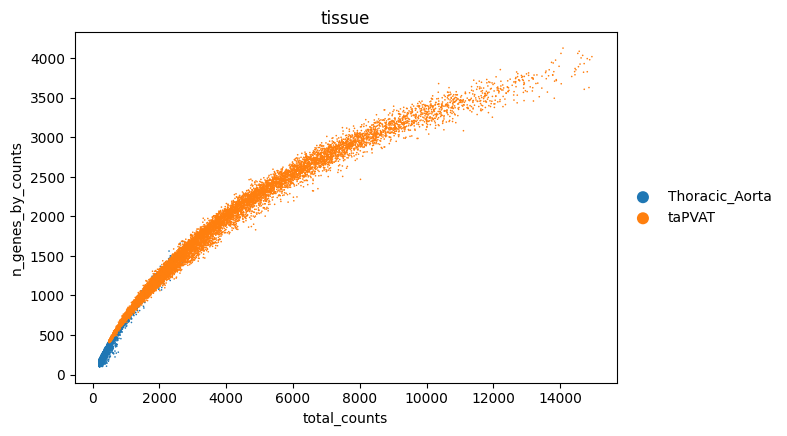

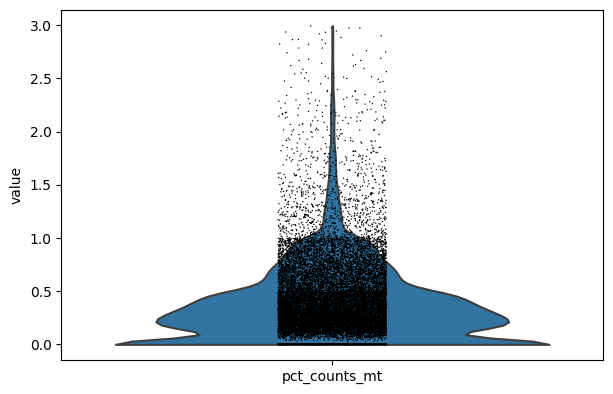

In [83]:
p1 = sc.pl.scatter(adata, "total_counts", "n_genes_by_counts", color="tissue")
p2 = sc.pl.violin(adata, "pct_counts_mt")

In [84]:
print(f"Total number of genes: {adata.n_vars}")
# Min 1 cells - filters out 0 count genes
sc.pp.filter_genes(adata, min_cells=3)
print(f"Number of genes after cell filter: {adata.n_vars}")

## Filter cells
print(f"Total number of cells: {adata.n_obs}")
sc.pp.filter_cells(adata, min_genes = 100)
print(f"Number of cells after gene filter: {adata.n_obs}")

Total number of genes: 23928
Number of genes after cell filter: 21298
Total number of cells: 21933
Number of cells after gene filter: 21933


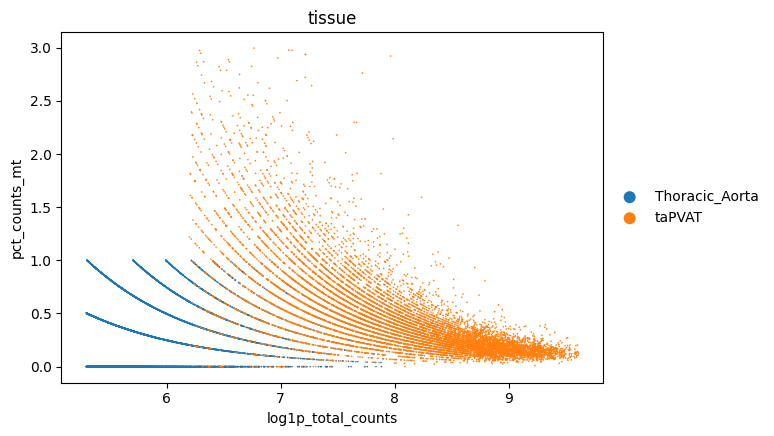

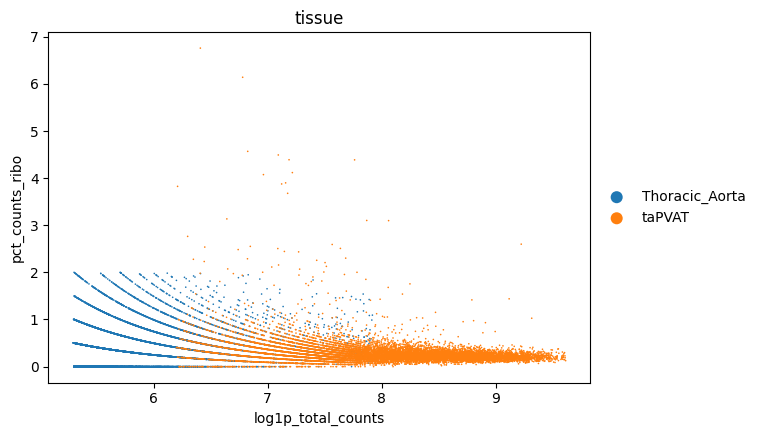

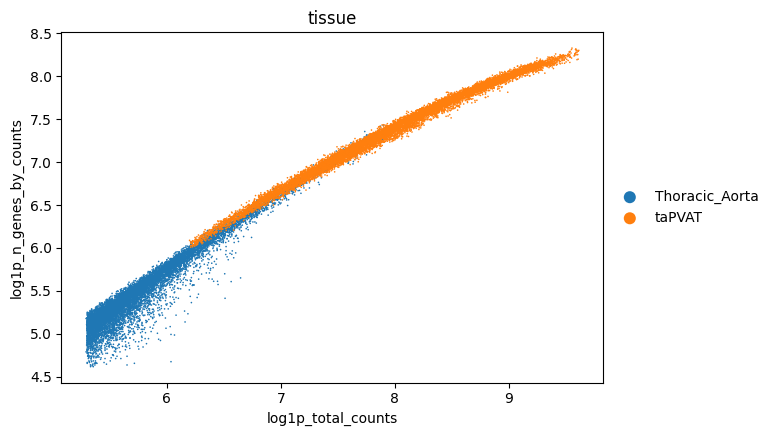

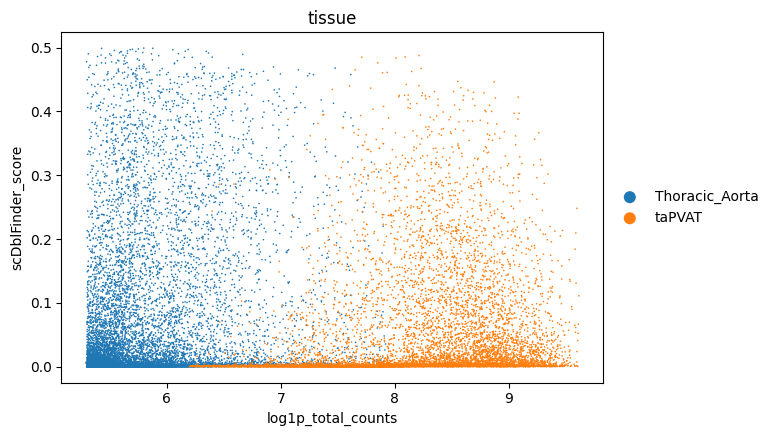

In [85]:
sc.pl.scatter(adata, x='log1p_total_counts', y='pct_counts_mt', color = 'tissue')
sc.pl.scatter(adata, x='log1p_total_counts', y='pct_counts_ribo', color = 'tissue')
sc.pl.scatter(adata, x='log1p_total_counts', y='log1p_n_genes_by_counts', color = 'tissue')
sc.pl.scatter(adata, x='log1p_total_counts', y='scDblFinder_score', color = 'tissue')

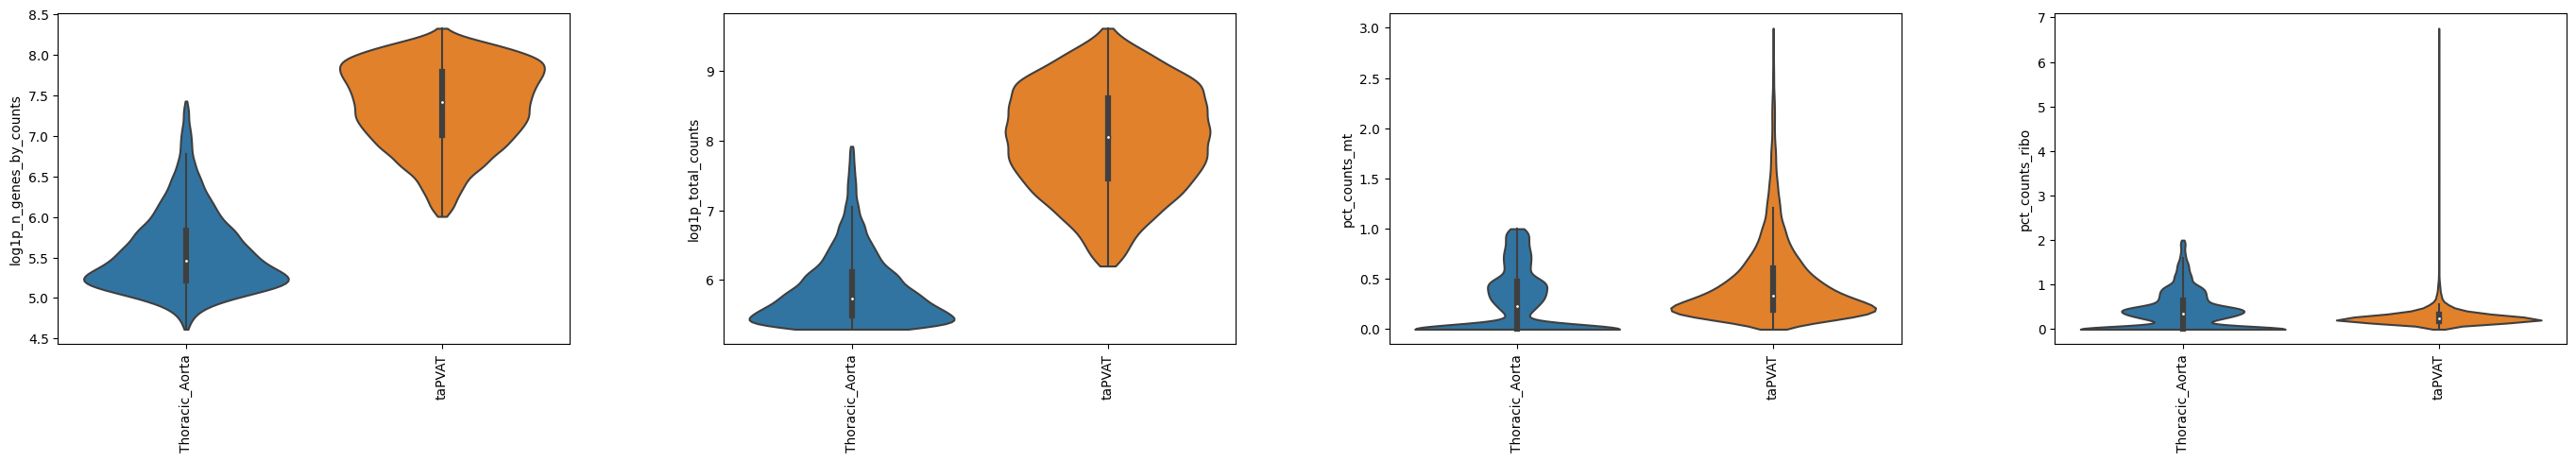

In [86]:
sc.pl.violin(adata, keys=['log1p_n_genes_by_counts', 'log1p_total_counts', 'pct_counts_mt', 'pct_counts_ribo'], groupby='tissue', rotation=90, stripplot = False, inner = 'box')

In [87]:
result = pd.DataFrame(adata.obs[['sample', 'sample_type']].value_counts().reset_index())
result.columns = ['sample', 'sample_type', 'total_count']
result

,sample,sample_type,total_count
0,TA_3,Thoracic_Aorta_Mesothelium,6464
1,P_CTRL_24W_M_02,taPVAT_Control_24W_M,6028
2,P_CTRL_24W_M_03,taPVAT_Control_24W_M,3634
3,TA_1,Thoracic_Aorta_Mesothelium,3555
4,P_CTRL_24W_M_01,taPVAT_Control_24W_M,1776
5,TA_2,Thoracic_Aorta_Mesothelium,476


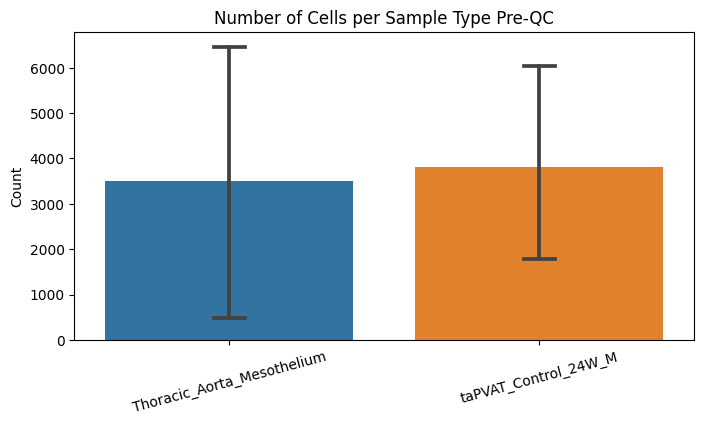

In [88]:
plt.figure(figsize=(8, 4))
ax = sns.barplot(x='sample_type', y='total_count', data=result, capsize = 0.1)
plt.title('Number of Cells per Sample Type Pre-QC')
plt.ylabel('Count')
plt.xlabel('')
plt.xticks(rotation=15)

plt.show()

In [89]:
### We'll normalize and log transform the data in adata here, and then we'll use the raw attribute to store the normalized and log-transformed data for later use in LIANA.
sc.pp.normalize_total(adata, target_sum=1e4)
sc.pp.log1p(adata)
adata.raw = adata

In [ ]:
adata.write_h5ad('../data/adata_meso_tapvat_combined_preprocessed.h5ad')